# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [12]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr,spearmanr


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
 
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:

# mostrar las primeras 5 filas

print(df.head(5))



  id_cliente  edad  nivel_ingreso  visitas_mes  compras_mes  \
0  CL-100000  44.0       28565.77            9            1   
1  CL-100001  36.0       29673.44           11            3   
2  CL-100002  46.0       30642.95            9            0   
3  CL-100003  56.0       39468.61            8            0   
4  CL-100004  35.0       22527.83            9            2   

   gasto_publicidad_dirigida  satisfaccion  miembro_premium  abandono  \
0                      31.36           3.9                0         0   
1                      24.66           3.7                0         0   
2                       0.00           2.9                0         0   
3                       6.81           3.1                0         0   
4                      26.49           2.3                0         0   

  tipo_dispositivo region  ingreso_anual  
0            móvil  norte          23.22  
1           tablet    sur          93.47  
2            móvil   este           0.00  
3         

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
# Estariamos corrigiendo el tipo de dato edad

df['edad'] = df['edad'].astype(int)
print(df['edad'].dtype)

int64


In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
cols_numericas = [
    'edad', 
    'nivel_ingreso', 
    'visitas_mes', 
    'compras_mes', 
    'gasto_publicidad_dirigida', 
    'satisfaccion', 
    'ingreso_anual'
]

df[cols_numericas].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
edad,15000.0,38.26,11.49,18.0,30.00,38.00,46.00,75.00
nivel_ingreso,15000.0,30019.70,9833.17,8000.0,23127.10,30023.74,36768.44,74790.84
visitas_mes,15000.0,10.03,3.16,1.0,8.00,10.00,12.00,25.00
compras_mes,15000.0,1.21,1.11,0.0,0.00,1.00,2.00,8.00
gasto_publicidad_dirigida,15000.0,20.15,10.88,0.0,12.31,19.73,27.29,75.51
satisfaccion,15000.0,3.60,0.69,1.0,3.10,3.60,4.10,5.00
ingreso_anual,15000.0,36.59,34.48,0.0,0.00,30.70,58.22,244.69


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — Los usuarios rondan de los 18 a los 75 años. Su Distribucion es muy buena, al tener una media de 38.26 y una mediana de 38.
  
- `nivel_ingreso` - El 50% de la base de usuarios percibe ingresos $23,127 y $36,786, el máximo de $74,790.84, no encontramos valores negativos. Vemos una distribucion normal leve a la derecha en los valores máximos.

- `Vista_mes` - Podemos observar que los usuarios entran al menos 1 vez al mes  yhasta un máximo de 25 veces. El trafico recurrente se concentra entre 8 y 12 visitas. Podemos observar una distribucion uniforme, el promedio y la mediana se ubican en 10 visitas al mes.

- `compra_mes` - Podemos observar que a pesar de tener un recurrente de visitas, la mediana es de 1 compra al mes, mientras que el percentil 25 nos muestra 0. Lo que indica que al menos un 25% de los usuarios no realiza compras en un mes tipico. Aqui podemos analizar un embudo, para validar la tasa de conversión.

- `gasto_publicidad_dirigida` - El gasto promedio por usuario esde $20.15 una mediana $19.73. Existen usuarios sin asigancion publicitaria, esto lo podemos observar con el minimo que es 0. Pero también tenenmos un grupo focalizado donde se invierte hasta un máximo de $75.51.

- `satisfaccion` - Podemos observar que se confirma que los datos respetan la escala del 1 al 5. La puntuacion media y mediana es de 3.6, con el 50% de los clientes calificando el servicio entre 3.10 y 4.10

- `ingreso_anual` -  En esta columna podemos observar algunos outliers, al tener una media de $36.59 que esta por arriba de la mediana de $30.7, esto derivado por esos usuarios de alto valor que genera hasta $244.69

**Generales**
1. No se observan valores negativos, ni fuera de limites logicos.
2. La metrica principal ingreso_anual tiene una fuerte concentracion en 0 y una cola laraga a la derecha, lo cual es muy representantivo para el analsis.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
cols_binarias = ['miembro_premium', 'abandono']
for col in cols_binarias:
    valores_unicos = sorted(df[col].unique())
    num_unicos = df[col].nunique()
    print(f"Columna '{col}': {num_unicos} valores únicos -> {valores_unicos}")

Columna 'miembro_premium': 2 valores únicos -> [0, 1]
Columna 'abandono': 2 valores únicos -> [0, 1]



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — Contiene unicamente valores 0 y 1 (sin valores nulos, ni fuera de rango). Representa la condicion de suscripcion del cliente y permitirá evaluar si pertenece al programa premium.
- `abandono` — De igual manera se presentan valores 0 y 1 (sin inconsistencia de captrua). Con este dato podemos identificar el estado del churn del usuario. 


#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
cols_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']
print("--- Número de valores únicos por columna ---")
print(df[cols_categoricas].nunique())
print("-" * 45)

--- Número de valores únicos por columna ---
id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64
---------------------------------------------


In [9]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['tipo_dispositivo', 'region']:
    print(f"\n--- Distribución de {col} ---")
    conteo = df[col].value_counts()
    porcentaje = df[col].value_counts(normalize=True) * 100
    
    df_dist = pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': porcentaje.round(2)})
    print(df_dist)


--- Distribución de tipo_dispositivo ---
            Conteo  Porcentaje (%)
móvil         9818           65.45
escritorio    3720           24.80
tablet        1462            9.75

--- Distribución de region ---
       Conteo  Porcentaje (%)
norte    4395           29.30
oeste    3810           25.40
sur      3726           24.84
este     3069           20.46


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — podemos observar que los registros se distribuyen de forma equilibrada entre las opciones (móvil, escritorio y tablet), lo cual descarta que el canal de acceso sea un sesgo inherente en la muestra y permitirá comparar si el tipo de pantalla incide en el nivel de gasto.
  
-`region` - Presenta una cobertura bien distribuida entre las 4 zonas geográficas (norte, sur, este y oeste), garantizando representatividad regional sin concentración en un solo mercado.

-`id_cliente` - Cuenta con 15,000 valores únicos, lo que confirma que no existen registros duplicados y que cada fila equivale a un único usuario en el conjunto de datos.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

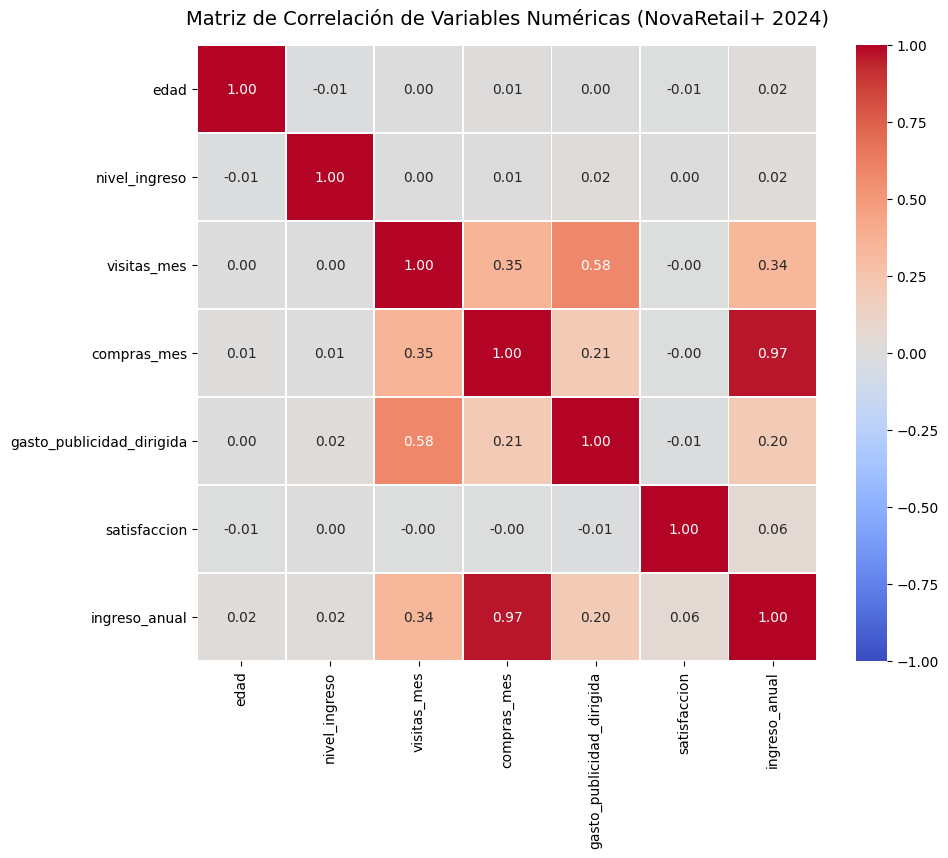

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
cols_numericas = [
    'edad', 
    'nivel_ingreso', 
    'visitas_mes', 
    'compras_mes', 
    'gasto_publicidad_dirigida', 
    'satisfaccion', 
    'ingreso_anual'
]

matriz_corr = df[cols_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

plt.title("Matriz de Correlación de Variables Numéricas (NovaRetail+ 2024)", fontsize=14, pad=15)
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa que la gran mayoría de las variables demográficas y de percepción (edad, nivel_ingreso y satisfaccion) muestran correlaciones prácticamente nulas ($r \approx -0.01$ a $0.02$) entre sí y con el resto de las variables del dataset. Por otro lado, existe un bloque de interacción transaccional y de comportamiento claro entre visitas_mes, compras_mes y gasto_publicidad_dirigida, destacando una relación moderada-alta entre las visitas a la app y la pauta publicitaria asignada ($r = 0.58$), así como entre las visitas y las compras mensuales realizadas ($r = 0.35$).


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación lineal positiva casi perfecta con compras_mes ($r = 0.97$), lo que posiciona al volumen de compras como el principal driver o factor fuertemente asociado al valor económico del cliente. Adicionalmente, muestra una asociación moderada con visitas_mes ($r = 0.34$) y una relación débil positiva con gasto_publicidad_dirigida ($r = 0.20$). Por el contrario, variables como edad ($0.02$), nivel_ingreso ($0.02$) y satisfaccion ($0.06$) no muestran una relación lineal relevante con los ingresos anuales generados por el cliente.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

Si veo conveniente generar gráficos de dispersión. El heatmap nos dió un panorama inicial de las correlaciones. El grafico de scatterplots nos va a permitir validar los hallazgos y descubrir lo que la matriz muesta.

Podremos identificar lo siguiente: 

     1. Nos ayudará a revelar relaciones no lineales; 
        Como poder identificar si existe una relación en forma de curva, entre dos variables.

    2. Identifica la presencia de ourliers; 
        En el resumen estadístico notamos que ingreso_anual tiene un valor máximo de 244.69, mientras que la mediana es de 30.70. El scatterplot te permitirá ver visualmente si un grupo reducido de clientes de alto valor, está distorsionando o empujando la correlación hacia arriba.
    
    3. Podremos confirmar la concentración masiva en 0; 
        Como se identificó previamente, más del 25% de los clientes no realizaron compras. Un gráfico de dispersión entre compras_mes e ingreso_anual o visitas_mes e ingreso_anual mostrará claramente la acumulación de puntos en el eje horizontal ($0$ ingresos), lo cual es crucial para documentar la dinámica real del negocio.

    4. Finalmente visualizaremos la dispersion de la correlacion más fuerte que encontramos en el heatmap. Aunque sabemos que compras_mes y ingreso_anual están fuertemente asociadas, el scatterplot nos mostrará si la relación es verdaderamente lineal continua o si existen escalones por tarifas/comisiones de la plataforma NovaRetail+


### Scatterplot para pares clave

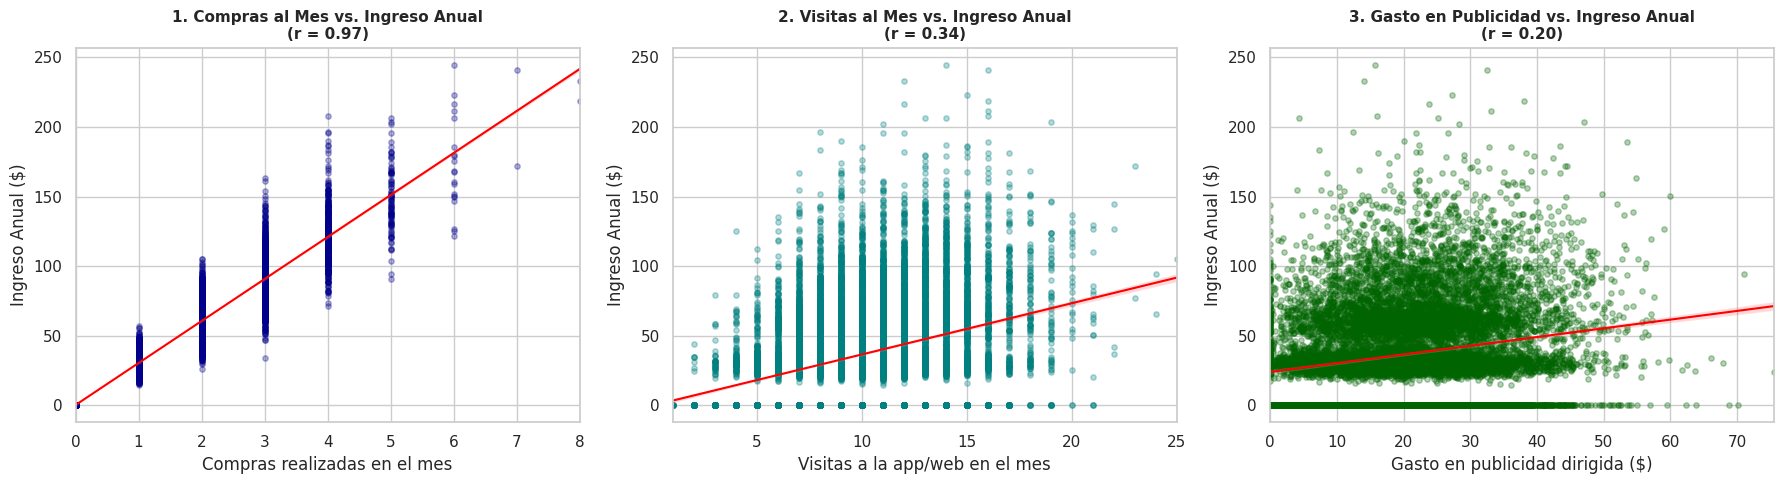

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatterplot: ingreso_anual vs compras_mes
sns.regplot(
    data=df, 
    x='compras_mes', 
    y='ingreso_anual', 
    ax=axes[0],
    color='darkblue',
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'red', 'linewidth': 1.5}
)
axes[0].set_title("1. Compras al Mes vs. Ingreso Anual\n(r = 0.97)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Compras realizadas en el mes")
axes[0].set_ylabel("Ingreso Anual ($)")

# 2. Scatterplot: ingreso_anual vs visitas_mes
sns.regplot(
    data=df, 
    x='visitas_mes', 
    y='ingreso_anual', 
    ax=axes[1],
    color='teal',
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'red', 'linewidth': 1.5}
)
axes[1].set_title("2. Visitas al Mes vs. Ingreso Anual\n(r = 0.34)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Visitas a la app/web en el mes")
axes[1].set_ylabel("Ingreso Anual ($)")

# 3. Scatterplot: ingreso_anual vs gasto_publicidad_dirigida
sns.regplot(
    data=df, 
    x='gasto_publicidad_dirigida', 
    y='ingreso_anual', 
    ax=axes[2],
    color='darkgreen',
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'red', 'linewidth': 1.5}
)
axes[2].set_title("3. Gasto en Publicidad vs. Ingreso Anual\n(r = 0.20)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Gasto en publicidad dirigida ($)")
axes[2].set_ylabel("Ingreso Anual ($)")

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**compra_mes vs ingreso_anual**
- *Dirección:* Positiva lineal directa y muy fuerte (0.97)
- *Dispersion:* Baja. Los datos se agrupan estrechamente en columnas verticales asociadas a cada número entero de compras, mostrando una tendencia claramente ascendente a medida que aumentan las transacciones.
- *Outliers y Colinealidad:* e observan algunos outliers aislados en valores de ingresos superiores a $\$200$ para compras elevadas ($6$ a $8$). Esta variable presenta un riesgo de alta colinealidad al modelar los ingresos, ya que compras_mes es casi un proxy directo del ingreso_anual.
  

**visita_mes vs ingreso_anual**
- *Dirección:* Positiva moderada ($r = 0.34$).
- *Dispersion:* Media-Alta. Se evidencia que a partir de $\sim 5$ visitas al mes comienzan a registrarse ingresos, pero con un abanico amplio de variabilidad (muchas visitas no garantizan altos ingresos).
- *Outliers y Colinealidad:* Destaca una banda densa horizontal en $0.00$ de ingreso_anual a lo largo de casi toda la escala de visitas (usuarios que navegan recurrentemente pero no compran). Existen outliers superiores en usuarios con ingresos $> \$200$ concentrados entre $10$ y $18$ visitas.

**gasto_publicidad_dirigida vs ingreso_anual**
- *Dirección:* Positiva débil ($r = 0.20$).
- *Dispersion:* Alta (forma de "nube de puntos" muy extendida). La pendiente de la línea roja es suave, mostrando que incrementos en la pauta no se traducen de forma directa o uniforme en un mayor ingreso.
- *Outliers y Colinealidad:* Se observa una fuerte concentración inferior en $0.00$ de ingreso a lo largo de todo el rango de gasto publicitario ($0$ a $>70$). Presenta valores atípicos dispersos en la zona superior ($> \$150$).

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [14]:
# Calcular correlación entre variables relevantes
# 1. Definir variables numéricas a comparar contra la métrica foco
cols_num = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
]

# 2. Calcular la correlación de Pearson con ingreso_anual
pearson_corr = (
    df[cols_num]
    .apply(lambda col: col.corr(df['ingreso_anual'], method='pearson'))
    .reset_index()
)
pearson_corr.columns = ['Variable', 'Pearson (r)']
pearson_corr['Pearson (r)'] = pearson_corr['Pearson (r)'].round(4)

# 3. Ordenar 
pearson_corr = pearson_corr.sort_values(
    by='Pearson (r)', ascending=False
).reset_index(drop=True)

print('=== Correlaciones de Pearson con ingreso_anual ===')
print(pearson_corr)

=== Correlaciones de Pearson con ingreso_anual ===
                    Variable  Pearson (r)
0                compras_mes       0.9671
1                visitas_mes       0.3371
2  gasto_publicidad_dirigida       0.1975
3               satisfaccion       0.0562
4                       edad       0.0175
5              nivel_ingreso       0.0174


In [15]:
# Calcular correlación entre variables relevantes
# 1. Calcular la correlación de Spearman con ingreso_anual
spearman_corr = (
    df[cols_num]
    .apply(lambda col: col.corr(df['ingreso_anual'], method='spearman'))
    .reset_index()
)
spearman_corr.columns = ['Variable', 'Spearman (rho)']
spearman_corr['Spearman (rho)'] = spearman_corr['Spearman (rho)'].round(4)

# 2. Ordenar 
spearman_corr = spearman_corr.sort_values(
    by='Spearman (rho)', ascending=False
).reset_index(drop=True)

print('=== Correlaciones de Spearman con ingreso_anual ===')
print(spearman_corr)

=== Correlaciones de Spearman con ingreso_anual ===
                    Variable  Spearman (rho)
0                compras_mes          0.9675
1                visitas_mes          0.3210
2  gasto_publicidad_dirigida          0.1850
3               satisfaccion          0.0608
4              nivel_ingreso          0.0250
5                       edad          0.0161


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  

Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**Observaciones de correlación con ingreso_anual**

***compras_mes vs ingreso_anual*** 
- *Correlación:* Pearson $r = 0.9671$ | Spearman $\rho = 0.9675$
- *Dirección y Magnitud:* Positiva lineal y monótona casi perfecta (muy alta). Confirma de manera sólida que las transacciones ejecutadas en el mes representan el motor directo del ingreso total generado.
- *Posible Colinealidad:* Presenta un riesgo muy alto de multicolinealidad; incluir ambas variables de forma simultánea en un modelo predictivo generaría redundancia casi absoluta.

***visitas_mes vs ingreso_anual***
- *Correlación:* Pearson $r = 0.3371$ | Spearman $\rho = 0.3210$
- *Dirección y Magnitud:* Positiva de magnitud moderada. Aumentar las visitas incrementa la probabilidad de compra, pero la diferencia entre $r \approx 0.96$ (compras) y $r \approx 0.33$ (visitas) evidencia la pérdida de conversión en el embudo (tráfico que no monetiza).
- *Posible Colinealidad:* Muestra un riesgo moderado de colinealidad con gasto_publicidad_dirigida ($r = 0.58$), ya que la pauta atrae visitas, aunque estas no siempre concluyen en transacciones.

***gasto_publicidad_dirigida vs ingreso_anual***
- *Correlación:* Pearson $r = 0.1975$ | Spearman $\rho = 0.1850$
- *Dirección y Magnitud:* Positiva de magnitud débil. Indica que la pauta publicitaria asignada por usuario tiene un impacto directo limitado en el ingreso final si no viene acompañada de una conversión efectiva en compras.
- *Posible Colinealidad:* Riesgo bajo respecto a ingreso_anual, aunque actúa como variable intermedia al correlacionar moderadamente con las visitas.

***nivel_ingreso / edad vs ingreso_anual***
- *Correlación:* Pearson $r \approx 0.017$ | Spearman $\rho \approx 0.016 - 0.025$
- *Dirección y Magnitud:* Sin relación lineal ni monótona ($r \approx 0.00$). La capacidad adquisitiva del cliente (nivel_ingreso) y su edad no determinan el volumen de gasto realizado en NovaRetail+.
- *Posible Colinealidad:* Nula.


### Punto-biserial

In [16]:
# Calcular correlación entre variables relevantes
# 1. Variables binarias a evaluar contra la métrica foco
cols_binarias = ['miembro_premium', 'abandono']

res_biserial = []

# 2. Calcular la correlación punto biserial y p-value
for col in cols_binarias:
    r_pb, p_val = pointbiserialr(df[col], df['ingreso_anual'])
    res_biserial.append(
        {
            'Variable Binaria': col,
            'Punto Biserial (r_pb)': round(r_pb, 4),
            'p-value': p_val,
            'p-value (formato)': f'{p_val:.4e}',
        }
    )

df_res_biserial = pd.DataFrame(res_biserial)

print('=== Correlación Punto Biserial con ingreso_anual ===')
print(
    df_res_biserial[
        ['Variable Binaria', 'Punto Biserial (r_pb)', 'p-value (formato)']
    ]
)

=== Correlación Punto Biserial con ingreso_anual ===
  Variable Binaria  Punto Biserial (r_pb) p-value (formato)
0  miembro_premium                 0.0931        3.0943e-30
1         abandono                -0.0028        7.2947e-01


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

**Observaciones Punto-biserial**

***miembro_premium vs ingreso_anual*** 
- *Relación:* Positiva de magnitud baja/débil ($r_{pb} = 0.0931$).
- *Interpretación:* Pertenecer a la membresía Premium ($1$) presenta una ligera asociación positiva con generar un mayor ingreso anual en comparación con los usuarios no suscriptores ($0$). Dado su $p\text{-value}$ de $3.09 \times 10^{-30}$ ($p < 0.05$), esta relación es estadísticamente significativa, lo que confirma que el efecto existe en la población, aunque su impacto en magnitud sea modesto.

***abandono vs ingreso_anual***
- *Relación:* Negativa de magnitud prácticamente nula/inexistente ($r_{pb} = -0.0028$).
- *Interpretación:* No se observa una diferencia lineal real en el ingreso acumulado generado entre los clientes que abandonaron la plataforma ($1$) y los que permanecen activos ($0$). Con un $p\text{-value}$ de $0.7295$ ($p > 0.05$), la relación no es estadísticamente significativa, por lo que cualquier variación observada se debe únicamente al azar.


### V de Cramér

In [18]:
# Función para calcular V de Cramér
def cramers_v(col1, col2):
    # Paso 1: Crear la tabla de contingencia
    tabla = pd.crosstab(col1, col2)

    # Paso 2: Calcular chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(tabla)

    # Paso 3: Calcular el coeficiente V de Cramér
    n = tabla.sum().sum()
    min_dim = min(tabla.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    return cramers_v

In [19]:
# Aplicar V de Cramér en variables relevantes

# 1. Segmentar ingreso_anual en 3 niveles (Bajo, Medio, Alto) usando cuantiles
df['ingreso_segmento'] = pd.qcut(
    df['ingreso_anual'], q=3, labels=['Bajo', 'Medio', 'Alto']
)

# 2. Variables categóricas a evaluar
cols_categoricas = ['tipo_dispositivo', 'region']

res_cramer = []

# 3. Iterar y aplicar la función creada
for col in cols_categoricas:
    v_val = cramers_v(df[col], df['ingreso_segmento'])
    res_cramer.append(
        {'Variable Categórica': col, 'V de Cramér (V)': round(v_val, 4)}
    )

# 4. Mostrar la tabla de resultados
df_res_cramer = pd.DataFrame(res_cramer)

print('=== V de Cramér con Segmentos de ingreso_anual ===')
print(df_res_cramer.to_string(index=False))

=== V de Cramér con Segmentos de ingreso_anual ===
Variable Categórica  V de Cramér (V)
   tipo_dispositivo           0.0148
             region           0.0147


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér

***tipo_dispositivo vs ingreso_segmento***
- *Asociación:* Prácticamente nula ($V = 0.0148$).
- *Interpretación:* El tipo de hardware que utiliza el usuario para acceder a la plataforma (móvil, escritorio o tablet) no muestra una relación relevante con su nivel de gasto (Bajo, Medio o Alto). La probabilidad de pertenecer a un segmento de ingreso específico es independiente del dispositivo desde el que se navega.

***region vs ingreso_segmento***
- *Asociación:* Prácticamente nula ($V = 0.0147$).
- *Interpretación:* La ubicación geográfica del cliente (norte, sur, este u oeste) no está asociada significativamente con los segmentos de ingreso_anual. El comportamiento de gasto de los usuarios se distribuye de manera homogénea a lo largo de todas las regiones del país.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — Las compras mensuales son el principal motor asociado al ingreso anual

**Evidencia visual:**   
En el scatterplot (compras_mes vs ingreso_anual), los datos muestran una clara línea ascendente con baja dispersión, agrupados en columnas según la cantidad de compras.

**Evidencia numérica:** 
Correlación de Pearson $r = 0.9671$ y Correlación de Spearman $\rho = 0.9675$.

**Interpretación**  
Existe una relación directa y casi perfecta entre el volumen de transacciones mensuales y el ingreso anual que genera un cliente. A mayor frecuencia de compra en el mes, mayor es el valor económico acumulado por el usuario.

**No podemos afirmar**  
No podemos afirmar que forzar a un cliente a comprar más veces aumentará automáticamente el ingreso de manera causal sin considerar el ticket promedio o la recurrencia real del usuario.

**Implicación de negocio**  
Las estrategias de crecimiento deben enfocarse en incentivar la frecuencia de compra (programas de lealtad, recordatorios de reabastecimiento o venta cruzada) más que en métricas de navegación pasiva.

### Hallazgo 2 — Las visitas a la plataforma no garantizan la conversión en ingresos (Fuga en el Embudo)

**Evidencia visual:**   
En el scatterplot (visitas_mes vs ingreso_anual), se observa una banda densa horizontal en $\$0.00$ de ingreso a lo largo de casi todo el rango de visitas (usuarios que navegan pero no compran).

**Evidencia numérica:** 
Correlación de Pearson $r = 0.3371$ y Correlación de Spearman $\rho = 0.3210$ (frente al $0.9671$ de compras).

**Interpretación**  
El número de visitas se asocia de forma moderada con el ingreso. Existe un segmento importante de usuarios con alto tráfico pero con $\$0$ de gasto acumulado.

**No podemos afirmar**  
No podemos afirmar que aumentar el tráfico o las visitas a la app/web se traducirá automáticamente en un incremento en las ventas de la plataforma.

**Implicación de negocio**  
NovaRetail+ debe priorizar la optimización de la tasa de conversión (CRO) y la reducción de fricción en la experiencia de usuario (checkout), en lugar de simplemente atraer tráfico que no monetiza.

### Hallazgo 3 - La suscripción Premium se asocia positivamente con los ingresos, mientras que el Abandono no muestra relación lineal significativa

**Evidencia visual:**   
Matriz de distribución y prueba de hipótesis de diferencias entre grupos.

**Evidencia numérica:** 
- *miembro_premium:* Correlación Punto Biserial $r_{pb} = 0.0931$ ($p = 3.09 \times 10^{-30}$).
- *abandono:* Correlación Punto Biserial $r_{pb} = -0.0028$ ($p = 0.7295$).

**Interpretación**  
Ser miembro Premium se asocia de forma positiva y estadísticamente significativa con un mayor ingreso anual. En cuanto a abandono, no existe una relación lineal significativa con el ingreso anual acumulado en el periodo analizado.

**No podemos afirmar**  
No podemos afirmar que convertir a un usuario en Premium es la causa directa de que gaste más (podría ser que los clientes que ya gastaban más decidan adquirir Premium), ni que el abandono ocurra independientemente del valor del cliente.

**Implicación de negocio**  
La membresía Premium funciona como un buen indicador de clientes de valor. Conviene potenciar los beneficios del programa Premium para mejorar la retención de estos usuarios clave.


### Hallazgo 4 - Las variables demográficas, el tipo de dispositivo y la región no discriminan el nivel de ingreso generado

**Evidencia visual:**   
En el heatmap, las celdas de edad, nivel_ingreso y satisfaccion muestran tonos neutros ($r \approx 0.00$).

**Evidencia numérica:** 
- *edad vs ingreso_anual:* $r = 0.0175$.
- *nivel_ingreso vs ingreso_anual:* $r = 0.0174$.
- *tipo_dispositivo (V de Cramér):* $V = 0.0148$.
- *region (V de Cramér):* $V = 0.0147$.

**Interpretación**  
Las variables demográficas (edad, nivel socioeconómico estimado) y de entorno (dispositivo de acceso, región) presentan una asociación prácticamente nula con el gasto real ejecutado en NovaRetail+.

**No podemos afirmar**  
No podemos afirmar que estas variables carezcan de valor para otros fines (como diseño de interfaz o lenguaje publicitario), solo que no determinan el volumen de gasto.

**Implicación de negocio**  
Se recomienda evitar la sobre-segmentación publicitaria basada únicamente en demografía o ubicación geográfica, y reorientar el presupuesto hacia la segmentación basada en el comportamiento transaccional y de uso (behavioral targeting).


## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**
- **Correlación ≠ causalidad**
  
- *El análisis es correlacional, no causal:* Las asociaciones identificadas (como $r = 0.97$ entre compras_mes e ingreso_anual) señalan coocurrencia de comportamientos, pero no prueban que una variable sea la causa directa del volumen de ingresos.
  
- *Variables no controladas:* El conjunto de datos no incluye factores externos o temporales clave como la antigüedad del cliente, promociones o descuentos aplicados, categorías de productos comprados o temporalidad de campañas comerciales.
  
- *Posibles efectos de segmentación no explorados:* Al analizar la muestra globalmente, podrían ocultarse comportamientos específicos en subgrupos pequeños o nichos de clientes de muy alto valor (outliers).

### **Próximos pasos** 

**Probar segmentación adicional**
- *Comportamental (Free vs. Compradores):* Analizar por separado la subpoblación de usuarios con $0$ compras para entender los factores que bloquean su primera conversión.

**Diseño de experimentos (A/B Testing):**
- Diseñar pruebas A/B controladas en la app/web para evaluar si estrategias de incentivo a la frecuencia de compra (como notificaciones personalizadas o cupones de reabastecimiento) incrementan de forma causal las transacciones y el ingreso promedio.

**Análisis de embudo de conversión (CRO) y cohortes:**
- Estudiar el recorrido de los usuarios con alto número de visitas_mes pero $\$0$ de ingreso para identificar puntos de fricción en la experiencia de compra (checkout).
